In [ ]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import mysql.connector
import numpy as np 

In [ ]:
#establishing connection 
conn = mysql.connector.connect(host = "localhost", 
                              username = "root", 
                              password = "Prasanthi@10",
                               database = "ecommerce_analysis"
                              )

cur = conn.cursor()  #establishing the connection

# 1. List all unique cities where customers are located 

In [3]:
query = """ select distinct customer_city from customers """ 

cur.execute(query)
data = cur.fetchall()
data

df = pd.DataFrame(data)
df.head()

,0
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas


# 2. Count the number of orders placed in 2017 

In [38]:
query = """ select count(order_id) from orders where year (order_purchase_timestamp) = 2017 """

cur.execute(query)
data = cur.fetchall()
data

[(45101,)]

# 3. Find total sales per category

In [96]:
query = """ select upper(products.product_category) category, round(sum(payments.payment_value), 2) sales
            from products join order_items 
            on products.product_id = order_items.product_id
            join payments
            on payments.order_id = order_items.order_id
            group by category """

cur.execute(query)
data = cur.fetchall()

df = pd.DataFrame(data, columns = ['Category', 'Sales'])
df

,Category,Sales
0,PERFUMERY,506738.66
1,FURNITURE DECORATION,1430176.39
2,TELEPHONY,486882.05
3,BED TABLE BATH,1712553.67
4,AUTOMOTIVE,852294.33
...,...,...
69,CDS MUSIC DVDS,1199.43
70,LA CUISINE,2913.53
71,FASHION CHILDREN'S CLOTHING,785.67
72,PC GAMER,2174.43


# 4. Calculate the percentage of orders that were paid in installments 

In [118]:
query = """ select sum(case when payment_installments >= 1 then 1 else 0 end)/count(*)*100 from payments """

cur.execute(query)
data = cur.fetchall()
data
"the percentage of orders that were paid in installements", data[0][0]

('the percentage of orders that were paid in installements',
 Decimal('99.9981'))

# 5. Count no.of customers in each state 

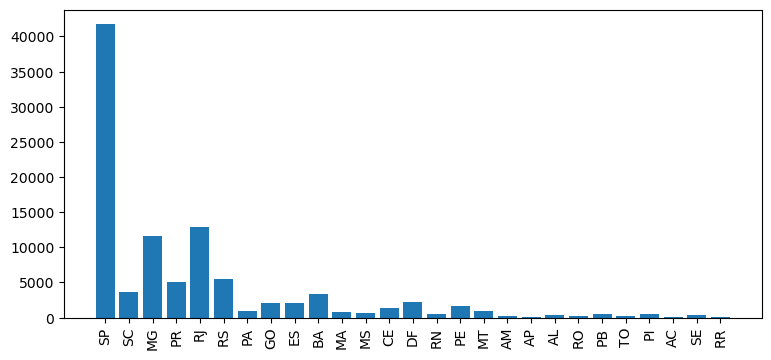

In [133]:
query = """ select customer_state, count(customer_id) from customers group by customer_state """

cur.execute(query)
data = cur.fetchall()
data

#dataframe
df = pd.DataFrame(data, columns = ['state', 'customer_count'])
df

#barplot 
plt.figure(figsize = (9, 4))
plt.bar(df['state'], df['customer_count'])
plt.xticks(rotation = 90)
plt.show()

# 6. Calculate the number of orders per month in 2018 

In [12]:
query = """ select month(order_purchase_timestamp) months, 
            count(order_id) orders from orders where 
            year(order_purchase_timestamp) = 2018 group by months""" 

cur.execute(query)
data = cur.fetchall()
data


df = pd.DataFrame(data, columns = ["months", "order_count"])
o = ["January", "February", "March", "April", "May", "June", "July", "August", "September", "October", "November", "December"]
df
#barplot 
# ax = sns.barplot(x = df["months"], y = df["order_count"], data = df,  order = o, color = "red")  # hue = df["months"], palette = "viridis"
# plt.xticks(rotation = 90)
# ax.bar_label(ax.containers[0])
#plt.xlabel('states')
#plt.ylabel('customer_count')
#plt.title('count of customers by states')
# plt.show()

,months,order_count
0,7,6292
1,8,6512
2,2,6728
3,6,6167
4,3,7211
5,1,7269
6,5,6873
7,4,6939
8,9,16
9,10,4


# 7. Find the average number of produts per order, grouped by customer city. 

In [231]:
query = """ with count_per_order as (select orders.order_id, orders.customer_id, count(order_items.order_id) as oc from orders join order_items 
on orders.order_id = order_items.order_id group by orders.order_id, orders.customer_id) select customers.customer_city, round(avg(count_per_order.oc), 2) average_orders
from customers join count_per_order
on customers.customer_id = count_per_order.customer_id
group by customers.customer_city order by average_orders desc
"""

cur.execute(query)
data = cur.fetchall()
data


df = pd.DataFrame(data, columns = ["customer_city", "average_products/orders"])
df.head(10)


,customer_city,average_products/orders
0,padre carvalho,7.00
1,celso ramos,6.50
2,datas,6.00
3,candido godoi,6.00
4,matias olimpio,5.00
5,cidelandia,4.00
6,picarra,4.00
7,morro de sao paulo,4.00
8,teixeira soares,4.00
9,curralinho,4.00


# 8. Calculate the percentage of total revenue contributed by each product category

In [270]:
query = """ select upper(products.product_category) category, round(sum(payments.payment_value)/round((select sum(payment_value)from payments))*100,2) sales
            from products join order_items 
            on products.product_id = order_items.product_id
            join payments
            on payments.order_id = order_items.order_id
            group by category order by sales desc;  """
cur.execute(query)
data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["category", "sales"])
df

#pie chart 
#pie chart is good to use on lesser values  6 or 8 
#plt.pie(df["sales"], labels = df["category"])
#plt.show()

,category,sales
0,BED TABLE BATH,10.70
1,HEALTH BEAUTY,10.35
2,COMPUTER ACCESSORIES,9.90
3,FURNITURE DECORATION,8.93
4,WATCHES PRESENT,8.93
...,...,...
69,HOUSE COMFORT 2,0.01
70,CDS MUSIC DVDS,0.01
71,PC GAMER,0.01
72,FASHION CHILDREN'S CLOTHING,0.00


# 9. Identify the correlation between product price and the number of times a product has been purchased. 

In [23]:
query = """ select products.product_category, count(order_items.product_id), round(avg(order_items.price),2) from products join order_items 
            on products.product_id = order_items.product_id group by products.product_category; """

cur.execute(query)
data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["category", "order_count", "price"])

arr1 = df["order_count"]
arr2 = df["price"]

a = np.corrcoef([arr1, arr2])  # as per result there's no impact of orders on the product 
print("the correlation between price & number of times a product has been purchased is", a[0][1])

#co-relation exits between -1 and +1, -1 = inversely proportional value. +1 = proportional value


the correlation between price & number of times a product has been purchased is -0.10631514167157562


# 10. Calculate the total revenue generated by each seller, and rank them by revenue.

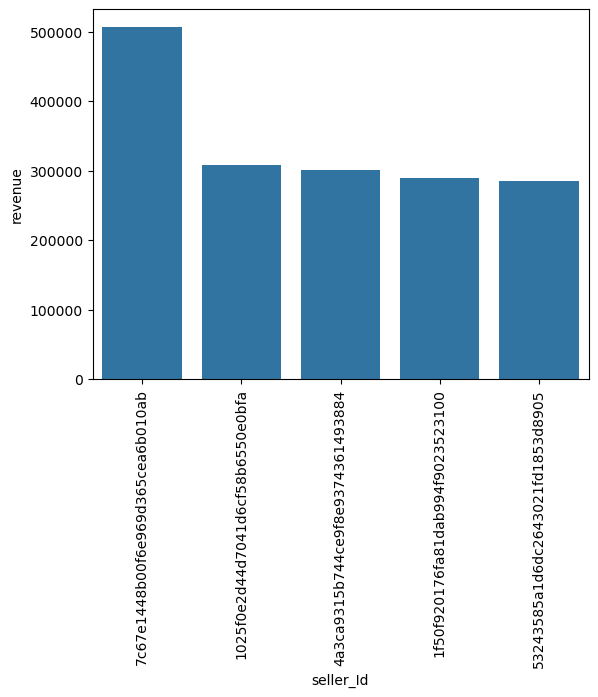

In [80]:
query = """ select *, dense_rank() over(order by revenue desc) as rn from 
            (select order_items.seller_id, sum(payments.payment_value) as revenue
            from order_items join payments on order_items.order_id = payments.order_id group by order_items.seller_id) as a """

cur.execute(query)
data = cur.fetchall()
data

df = pd.DataFrame(data, columns = ["seller_Id", "revenue", "rank"])
df = df.head()
sns.barplot(x = "seller_Id", y = "revenue", data = df)
plt.xticks(rotation = 90)
plt.show()


# 11. Calculate the moving average of order values for each customer over their order history.

In [95]:
query = """ select customer_id, order_purchase_timestamp, payment, avg(payment) over(partition by customer_id order by order_purchase_timestamp
                rows between 2 preceding and current row) as mov_avg 
                from
            (select orders.customer_id, orders.order_purchase_timestamp, payments.payment_value as payment
            from payments join orders on payments.order_id = orders.order_id) as a """

cur.execute(query)
data = cur.fetchall()
data

df = pd.DataFrame(data)
df


,0,1,2,3
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.74,114.739998
1,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.41,67.410004
2,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.42,195.419998
3,0002414f95344307404f0ace7a26f1d5,2017-08-16 13:09:20,179.35,179.350006
4,000379cdec625522490c315e70c7a9fb,2018-04-02 13:42:17,107.01,107.010002
...,...,...,...,...
103881,fffecc9f79fd8c764f843e9951b11341,2018-03-29 16:59:26,0.64,27.120001
103882,fffeda5b6d849fbd39689bb92087f431,2018-05-22 13:36:02,63.13,63.130001
103883,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.13,214.130005
103884,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.50,45.500000


# 12. Calculate the cumulative sales per month for each year.

In [120]:
query = """ select years, months, payments, sum(payments) 
            over(order by years, months) cumulative_sales 
            from
            (
            select year(orders.order_purchase_timestamp) 
            as years, 
            month(orders.order_purchase_timestamp) as months, 
            round(sum(payments.payment_value),2) as payments 
            from orders 
            join payments on orders.order_id = payments.order_id
            group by years, months 
            order by years, months
            ) as a; """

cur.execute(query)
data = cur.fetchall()
data

df = pd.DataFrame(data)
df

,0,1,2,3
0,2016,9,252.24,252.24
1,2016,10,59090.48,59342.72
2,2016,12,19.62,59362.34
3,2017,1,138488.04,197850.38
4,2017,2,291908.01,489758.39
5,2017,3,449863.60,939621.99
6,2017,4,417788.03,1357410.02
7,2017,5,592918.82,1950328.84
8,2017,6,511276.38,2461605.22
9,2017,7,592382.92,3053988.14


# 13. Calculate year or year growth rate of total sales.

In [151]:
query = """ with a as
            (select year(orders.order_purchase_timestamp) as years, 
            round(sum(payments.payment_value),2) as payment from orders 
            join payments on orders.order_id = payments.order_id
            group by years order by years)

            select years, (payment - lag(payment, 1) over(order by years))/ lag(payment, 1) over (order by years) from a """
cur.execute(query)
data = cur.fetchall()
data

# df = pd.DataFrame(data, columns = ["year", "sales", "previous_year"])

df = pd.DataFrame(data, columns = ["year", "yoy % growth"])
df

,year,yoy % growth
0,2016,NaN
1,2017,121.127038
2,2018,0.200009


# 14. Calculate the retention of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase 

In [179]:
query = """ with a as 
            (select customers.customer_id, min(orders.order_purchase_timestamp) first_order
            from customers join orders on 
            customers.customer_id = orders.customer_id
            group by customers.customer_id)  
            
            select a.customer_id, count(distinct orders.order_purchase_timestamp) from a join orders on 
            orders.customer_id = a.customer_id
            and orders.order_purchase_timestamp > first_order
            and orders.order_purchase_timestamp < date_add(first_order, interval 6 month) group by a.customer_id

          
            """

cur.execute(query)
data = cur.fetchall()
data

#no customer found who bought within 6 months

[]

# 15. Identify the top 3 customers who spent the most money in each year.

In [192]:
query = """ 

            (select orders.order_id, orders.customer_id, sum(payments.payment_value) payment, 
            dense_rank() over (order by sum(payments.payment_value) desc) 
            from orders join payments on 
            payments.order_id = orders.order_id group by orders.order_id, orders.customer_id)   """


cur.execute(query)
data = cur.fetchall()
data


df = pd.DataFrame(data)
df

,0,1,2,3
0,03caa2c082116e1d31e67e9ae3700499,1617b1357756262bfa56ab541c47bc16,13664.080078,1
1,736e1922ae60d0d6a89247b851902527,ec5b2ba62e574342386871631fafd3fc,7274.879883,2
2,0812eb902a67711a1cb742b3cdaa65ae,c6e2731c5b391845f6800c97401a43a9,6929.310059,3
3,fefacc66af859508bf1a7934eab1e97f,f48d464a0baaea338cb25f816991ab1f,6922.209961,4
4,f5136e38d1a14a4dbd87dff67da82701,3fd6777bbce08a352fddd04e4a7cc8f6,6726.660156,5
...,...,...,...,...
99435,e8bbc1d69fee39eee4c72cb5c969e39d,184e8e8e48937145eb96c721ef1f0747,10.070000,29367
99436,f1d5c2e6867fa93ceee9ef9b34a53cbf,a790343ca6f3fee08112d678b43aa7c5,9.590000,29368
99437,4637ca194b6387e2d538dc89b124b0ee,a73c1f73f5772cf801434bf984b0b1a7,0.000000,29369
99438,c8c528189310eaa44a745b8d9d26908b,197a2a6a77da93f678ea0d379f21da0a,0.000000,29369


In [ ]:
query = """ select year(orders.order_purchase_timestamp) years,  orders.customer_id, sum(payments.payment_value) payment, 
            dense_rank() over (partition by year(orders.order_purchase_timestamp)
            order by sum(payments.payment_value) desc) 
            from orders join payments on 
            payments.order_id = orders.order_id group by year(orders.order_purchase_timestamp), orders.customer_id;  """


cur.execute(query)
data = cur.fetchall()
df = pd.DataFrame(data, columns = ["years", "id", "payments", "rank"])

sns.barplot(x = "id", y = "payments", data = df, hue = "years")
plt.xticks(rotation = 45)
plt.show()